In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.preprocessing import LabelEncoder
import shap
import warnings
warnings.filterwarnings('ignore')

# Dataset

In [ ]:
from sklearn.datasets import load_diabetes
import pandas as pd

data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # ajouter target à df d'abord
df_original = df.copy()     #  ensuite copier
# Rendre la target catégorielle pour tester le cas général
df_original['target'] = df_original['target'].astype('category')
num_cols = df_original.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_original.select_dtypes(include=['category', 'object']).columns.tolist()

print(f"Colonnes numériques : {num_cols}")
print(f"Colonnes catégorielles : {cat_cols}")
print(f"Shape : {df_original.shape}")
df_original.head()

Colonnes numériques : ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Colonnes catégorielles : ['target']
Shape : (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [ ]:
data = load_iris(as_frame=True)
df_original = data.frame.copy()

# Rendre la target catégorielle pour tester le cas général
df_original['target'] = df_original['target'].astype('category')

num_cols = df_original.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_original.select_dtypes(include=['category', 'object']).columns.tolist()

print(f"Colonnes numériques : {num_cols}")
print(f"Colonnes catégorielles : {cat_cols}")
print(f"Shape : {df_original.shape}")
df_original.head()

Colonnes numériques : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Colonnes catégorielles : ['target']
Shape : (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
#encodage
df_encoded = df_original.copy()
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = df_encoded[col].astype(object)
    mask = df_encoded[col].notna()
    df_encoded.loc[mask, col] = le.fit_transform(df_encoded.loc[mask, col].astype(str))
    df_encoded[col] = pd.to_numeric(df_encoded[col], errors='coerce')
    encoders[col] = le

print("Encodage terminé.")
df_encoded.head()

Encodage terminé.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# Missing Rate

In [ ]:
np.random.seed(42)
missing_rate = 0.35

df_missing = df_encoded.copy().astype(float)
missing_positions = []  # liste de tuples (index_ligne, nom_colonne)

for col in df_missing.columns:
    mask = np.random.rand(len(df_missing)) < missing_rate
    df_missing.loc[mask, col] = np.nan
    for idx in df_missing.index[mask]:
        missing_positions.append((idx, col))

n_missing = df_missing.isna().sum().sum()
print(f"Valeurs manquantes : {n_missing} ({100 * n_missing / df_missing.size:.1f}%)")
print(f"Nombre de positions manquantes : {len(missing_positions)}")
print(f"5 premières : {missing_positions[:5]}")

Valeurs manquantes : 270 (36.0%)
Nombre de positions manquantes : 270
5 premières : [(4, 'sepal length (cm)'), (5, 'sepal length (cm)'), (6, 'sepal length (cm)'), (10, 'sepal length (cm)'), (13, 'sepal length (cm)')]


In [ ]:
df_missing

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,NaN,0.2,NaN
1,4.9,NaN,1.4,0.2,NaN
2,4.7,NaN,1.3,0.2,NaN
3,4.6,3.1,1.5,0.2,NaN
4,NaN,3.6,1.4,NaN,NaN
...,...,...,...,...,...
145,NaN,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,NaN,5.2,NaN,2.0
148,NaN,3.4,5.4,NaN,2.0


#Imputation intiale

# 1.KNN

In [ ]:
knn_imputer = KNNImputer(n_neighbors=5)
df_knn_array = knn_imputer.fit_transform(df_missing)
df_knn_imputed = pd.DataFrame(df_knn_array, columns=df_missing.columns, index=df_missing.index)

print("Imputation KNN terminée.")
df_knn_imputed.head()

Imputation KNN terminée.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.50,1.44,0.20,0.0
1,4.9,3.40,1.40,0.20,0.0
2,4.7,3.48,1.30,0.20,0.0
3,4.6,3.10,1.50,0.20,0.2
4,4.9,3.60,1.40,0.26,0.0


# 2.MICE

In [ ]:
from sklearn.impute import SimpleImputer

df_knn_imputed = df_missing.copy()

# Moyenne pour les colonnes numériques
if num_cols:
    mean_imputer = SimpleImputer(strategy='mean')
    df_knn_imputed[num_cols] = mean_imputer.fit_transform(df_missing[num_cols])

# Mode pour les colonnes catégorielles
if cat_cols:
    mode_imputer = SimpleImputer(strategy='most_frequent')
    df_knn_imputed[cat_cols] = mode_imputer.fit_transform(df_missing[cat_cols])

print("Imputation Moyenne/Mode terminée.")
df_knn_imputed.head()

Imputation Moyenne/Mode terminée.


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.005363,0.001857,0.061696,0.000469,-0.000084,-0.034821,-0.000346,0.000792,0.004296,-0.003314,37.0
1,-0.001882,0.001857,-0.001222,-0.026328,-0.000084,-0.019163,-0.000346,-0.039493,0.004296,-0.003314,191.0
2,0.085299,0.050680,0.044451,-0.005670,-0.000084,0.000166,-0.032356,-0.002592,0.002861,-0.025930,37.0
3,0.005363,-0.044642,-0.001222,0.000469,0.012191,0.024991,-0.000346,0.000792,0.004296,-0.009362,87.0
4,0.005363,-0.044642,-0.001222,0.000469,0.003935,0.015596,0.008142,0.000792,0.004296,-0.003314,37.0


# 3. Moyenne/Mode

In [ ]:
from sklearn.linear_model import BayesianRidge

mice_imputer = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=10,
    random_state=42,
    verbose=0
)

df_mice_array = mice_imputer.fit_transform(df_missing)
df_knn_imputed = pd.DataFrame(df_mice_array, columns=df_missing.columns, index=df_missing.index)

print("Imputation MICE terminée.")
df_knn_imputed.head()

Imputation MICE terminée.


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.013043,0.001782,0.061696,0.043748,-0.013897,-0.034821,-0.017922,0.003051,0.030701,0.035605,104.318525
1,-0.001882,-0.020304,-0.022179,-0.026328,-0.026492,-0.019163,0.035889,-0.039493,-0.029804,-0.030083,191.000000
2,0.085299,0.050680,0.044451,-0.005670,-0.006612,-0.002245,-0.032356,-0.002592,0.002861,-0.025930,56.747981
3,0.021179,-0.044642,0.000496,-0.000896,0.012191,0.024991,0.000627,0.004865,-0.016762,-0.009362,87.000000
4,0.000657,-0.044642,0.004237,-0.010425,0.003935,0.015596,0.008142,-0.001143,-0.008906,-0.028297,129.654262


# Imputation par Missforest

In [ ]:
rf_estimator = RandomForestRegressor(
    n_estimators=100,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

mf_imputer = IterativeImputer(
    estimator=rf_estimator,
    max_iter=10,
    random_state=42,
    verbose=0
)

df_mf_array = mf_imputer.fit_transform(df_missing)
df_mf_imputed = pd.DataFrame(df_mf_array, columns=df_missing.columns, index=df_missing.index)

print("Imputation MissForest terminée.")
df_mf_imputed.head()

Imputation MissForest terminée.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.10,3.500,1.558,0.200,0.00
1,4.90,3.286,1.400,0.200,0.00
2,4.70,3.154,1.300,0.200,0.01
3,4.60,3.100,1.500,0.200,0.01
4,5.02,3.600,1.400,0.222,0.00


# Calcul de score de fiabilité par l'erreur additivité de shap

# Etape 1 :

1.Executer SHAP (10 itérations) sur le dataset imputé par l'imputation initiale

2.Calculer l'erreur :

$$
\epsilon = \left| f(\text{x_impute}) - \left( \phi_0 + \sum_i \phi_i \right) \right|
$$

In [ ]:
n_iterations = 10

# Structure : {(i, j): {'shap_iter': [], 'base_iter': [], 'features': []}}
# On accumule les résultats de chaque itération avant de moyenner
temp_storage = {}
for (i, j) in missing_positions:
    temp_storage[(i, j)] = {'shap_iter': [], 'base_iter': [], 'features': []}

# Grouper les positions manquantes par colonne
cols_with_missing = {}
for (i, j) in missing_positions:
    if j not in cols_with_missing:
        cols_with_missing[j] = []
    cols_with_missing[j].append(i)

# N itérations
for it in range(n_iterations):
    rs = 42 + it

    for j in cols_with_missing:
        feature_cols = [c for c in df_knn_imputed.columns if c != j]

        # Entraînement sur les lignes non manquantes
        train_mask = df_missing[j].notna()
        X_train = df_knn_imputed.loc[train_mask, feature_cols].values
        y_train = df_knn_imputed.loc[train_mask, j].values

        rf = RandomForestRegressor(n_estimators=100, max_features='sqrt', random_state=rs, n_jobs=-1)
        rf.fit(X_train, y_train)

        explainer = shap.TreeExplainer(rf)

        # SHAP sur toutes les lignes manquantes de la colonne j en même temps
        rows_idx = cols_with_missing[j]
        X_to_explain = df_knn_imputed.loc[rows_idx, feature_cols].values
        shap_vals = explainer.shap_values(X_to_explain)   # shape (n_lignes_manquantes, n_features)
        base_val = float(explainer.expected_value)

        # Stocker pour chaque cellule (i, j)
        for k, i in enumerate(rows_idx):
            temp_storage[(i, j)]['shap_iter'].append(shap_vals[k])
            temp_storage[(i, j)]['base_iter'].append(base_val)
            temp_storage[(i, j)]['features'] = feature_cols

    print(f"Itération {it + 1}/{n_iterations} terminée")

# Agrégation finale par moyenne
aggregated_shap = {}

for (i, j) in missing_positions:
    shap_stack = np.array(temp_storage[(i, j)]['shap_iter'])   # (n_iterations, n_features)
    base_stack = np.array(temp_storage[(i, j)]['base_iter'])   # (n_iterations,)

    aggregated_shap[(i, j)] = {
        'shap_values_mean': shap_stack.mean(axis=0),
        'shap_values_std':  shap_stack.std(axis=0),
        'base_value_mean':  float(base_stack.mean()),
        'predicted_mean':   float(base_stack.mean() + shap_stack.mean(axis=0).sum()),
        'features':         temp_storage[(i, j)]['features']
    }

print(f"\nAgrégation terminée. {len(aggregated_shap)} cellules traitées.")

Itération 1/10 terminée
Itération 2/10 terminée
Itération 3/10 terminée
Itération 4/10 terminée
Itération 5/10 terminée
Itération 6/10 terminée
Itération 7/10 terminée
Itération 8/10 terminée
Itération 9/10 terminée
Itération 10/10 terminée

Agrégation terminée. 270 cellules traitées.


# Etape 2 :  calculer le score de confiance

$$
\text{score} = \frac{1}{1 + |\epsilon|}
$$

In [ ]:
records = []

for (idx, col) in missing_positions:
    if (idx, col) not in aggregated_shap:
        continue

    shap_info = aggregated_shap[(idx, col)]

    val_missforest = df_mf_imputed.loc[idx, col]
    val_shap = shap_info['predicted_mean']  # base_value_mean + sum(shap_values_mean)

    abs_error = abs(val_missforest - val_shap)
    score = 1 / (1 + abs_error)

    records.append({
        'row': idx,
        'col': col,
        'val_missforest': round(val_missforest, 4),
        'val_shap_reconstruction': round(val_shap, 4),
        'base_value': round(shap_info['base_value_mean'], 4),
        'shap_sum': round(shap_info['shap_values_mean'].sum(), 4),
        'abs_error': round(abs_error, 4),
        'confidence_score': round(score, 4)
    })

results_df = pd.DataFrame(records)
print(results_df.to_string(index=False))

 row               col  val_missforest  val_shap_reconstruction  base_value  shap_sum  abs_error  confidence_score
   4 sepal length (cm)           5.020                   4.9057      5.7952   -0.8896     0.1143            0.8974
   5 sepal length (cm)           5.140                   4.8461      5.7952   -0.9492     0.2939            0.7729
   6 sepal length (cm)           5.082                   4.8759      5.7952   -0.9193     0.2061            0.8291
  10 sepal length (cm)           5.146                   5.1071      5.7952   -0.6881     0.0389            0.9626
  13 sepal length (cm)           4.560                   4.6962      5.7952   -1.0991     0.1362            0.8801
  14 sepal length (cm)           4.740                   4.8063      5.7952   -0.9890     0.0663            0.9378
  15 sepal length (cm)           5.179                   5.1583      5.7952   -0.6369     0.0207            0.9797
  16 sepal length (cm)           4.520                   4.6968      5.7952   -1

In [ ]:
# Summary par variable
summary = results_df.groupby('col').agg(
    n_missing=('row', 'count'),
    mean_abs_error=('abs_error', 'mean'),
    mean_score=('confidence_score', 'mean'),
    min_score=('confidence_score', 'min'),
    max_score=('confidence_score', 'max')
).round(4)

print("=" * 55)
print("RÉSUMÉ PAR COLONNE")
print("=" * 55)
print(summary.to_string())

print("\n" + "=" * 55)
print(f"Score de confiance global moyen : {results_df['confidence_score'].mean():.4f}")
print(f"Erreur absolue moyenne          : {results_df['abs_error'].mean():.4f}")
print(f"Nb total de valeurs analysées   : {len(results_df)}")

print("\nTop 5 imputations les moins fiables :")
print(results_df.nsmallest(5, 'confidence_score')[
    ['row', 'col', 'val_missforest', 'val_shap_reconstruction', 'abs_error', 'confidence_score']
].to_string(index=False))

RÉSUMÉ PAR COLONNE
                   n_missing  mean_abs_error  mean_score  min_score  max_score
col                                                                           
petal length (cm)         50          0.2062      0.8577     0.4172     0.9970
petal width (cm)          46          0.1426      0.8858     0.6581     0.9949
sepal length (cm)         63          0.2002      0.8483     0.5436     1.0000
sepal width (cm)          51          0.1562      0.8757     0.6763     0.9994
target                    60          0.0869      0.9412     0.4970     1.0000

Score de confiance global moyen : 0.8822
Erreur absolue moyenne          : 0.1580
Nb total de valeurs analysées   : 270

Top 5 imputations les moins fiables :
 row               col  val_missforest  val_shap_reconstruction  abs_error  confidence_score
  18 petal length (cm)           2.994                   1.5973     1.3967            0.4172
  42            target           0.960                   1.9720     1.0120        

# Sauvegarde des résultats dans fichier CSV

In [ ]:
from sklearn.metrics import mean_absolute_error, f1_score, accuracy_score, roc_auc_score
from scipy.stats import spearmanr
import os

# ---- On change ces 3 variables manuellement avant chaque exécution ----
dataset_name      = 'adult'
missing_rate      = 0.05
imputation_method = 'KNN'
# ------------------------------------------------------------------------

# Récupérer les vraies valeurs depuis df_encoded pour chaque position manquante
true_vals      = []
mf_vals        = []
shap_vals_rec  = []
scores         = []
errors         = []
cols_list      = []

for _, row in results_df.iterrows():
    i   = row['row']
    col = row['col']

    true_val = df_encoded.loc[i, col]
    true_vals.append(true_val)
    mf_vals.append(row['val_missforest'])
    shap_vals_rec.append(row['val_shap_reconstruction'])
    scores.append(row['confidence_score'])
    errors.append(row['abs_error'])
    cols_list.append(col)

true_vals     = np.array(true_vals)
mf_vals       = np.array(mf_vals)
shap_vals_rec = np.array(shap_vals_rec)
scores        = np.array(scores)
errors        = np.array(errors)

# --- Erreur réelle (vraie valeur vs missforest) ---
real_error_mf   = np.abs(true_vals - mf_vals)
real_error_shap = np.abs(true_vals - shap_vals_rec)

# --- MAE ---
mae_missforest = mean_absolute_error(true_vals, mf_vals)
mae_shap       = mean_absolute_error(true_vals, shap_vals_rec)

# --- RMSE ---
rmse_missforest = np.sqrt(np.mean((true_vals - mf_vals) ** 2))
rmse_shap       = np.sqrt(np.mean((true_vals - shap_vals_rec) ** 2))

# --- Accuracy et F1 pour les colonnes catégorielles uniquement ---
cat_mask = np.array([c in cat_cols for c in cols_list])

if cat_mask.sum() > 0:
    true_cat = true_vals[cat_mask].astype(int)
    mf_cat   = mf_vals[cat_mask].round().astype(int)

    accuracy = accuracy_score(true_cat, mf_cat)
    f1       = f1_score(true_cat, mf_cat, average='macro', zero_division=0)
else:
    accuracy = None
    f1       = None

# --- Corrélation Spearman entre confidence_score et erreur réelle ---
# On attend une corrélation négative : score bas = erreur réelle grande
corr_spearman, pval_spearman = spearmanr(scores, real_error_mf)

# --- AUC-ROC : score de confiance comme prédicteur de "mauvaise imputation" ---
# On définit "mauvaise imputation" = erreur réelle > 1 std
threshold        = real_error_mf.mean() + real_error_mf.std()
bad_imputation   = (real_error_mf > threshold).astype(int)

if bad_imputation.sum() > 0 and bad_imputation.sum() < len(bad_imputation):
    # Le score est inversé car score bas = mauvaise imputation
    auc_roc = roc_auc_score(bad_imputation, 1 - scores)
else:
    auc_roc = None

# --- Moyenne du confidence score ---
mean_score = scores.mean()
std_score  = scores.std()

# --- Affichage ---
print("=" * 55)
print(f"MÉTRIQUES — {dataset_name} | {imputation_method} | missing={int(missing_rate*100)}%")
print("=" * 55)
print(f"MAE MissForest          : {mae_missforest:.4f}")
print(f"MAE SHAP reconstruction : {mae_shap:.4f}")
print(f"RMSE MissForest         : {rmse_missforest:.4f}")
print(f"RMSE SHAP               : {rmse_shap:.4f}")
print(f"mean_shap_error         : {results_df['abs_error'].mean():.4f}")
print(f"std_shap_error          : {results_df['abs_error'].std():.4f}")
print(f"Accuracy (cat)          : {accuracy}")
print(f"F1 score (cat)          : {f1}")
print(f"Corrélation Spearman    : {corr_spearman:.4f} (p={pval_spearman:.4f})")
print(f"AUC-ROC                 : {auc_roc}")
print(f"Confidence score moyen  : {mean_score:.4f} ± {std_score:.4f}")
print("=" * 55)

# --- Construction de la ligne résumé ---
summary_row = {
    'dataset'           : dataset_name,
    'missing_rate'      : missing_rate,
    'imputation_method' : imputation_method,
    'mae_missforest'    : round(mae_missforest, 4),
    'mae_shap'          : round(mae_shap, 4),
    'rmse_missforest'   : round(rmse_missforest, 4),
    'rmse_shap'         : round(rmse_shap, 4),
    'mean_shap_error'   : round(results_df['abs_error'].mean(), 4),   # <-- ajouté
    'std_shap_error'    : round(results_df['abs_error'].std(), 4),    # <-- ajouté
    'accuracy'          : round(accuracy, 4) if accuracy is not None else None,
    'f1_score'          : round(f1, 4) if f1 is not None else None,
    'spearman_corr'     : round(corr_spearman, 4),
    'spearman_pval'     : round(pval_spearman, 4),
    'auc_roc'           : round(auc_roc, 4) if auc_roc is not None else None,
    'mean_confidence'   : round(mean_score, 4),
    'std_confidence'    : round(std_score, 4),
    'n_missing_cells'   : len(results_df)
}
summary_df = pd.DataFrame([summary_row])

# --- Sauvegarde dans le CSV global ---
global_csv = 'toutes_experiences.csv'

if os.path.exists(global_csv):
    summary_df.to_csv(global_csv, mode='a', header=False, index=False)
    print(f"Ligne ajoutée à {global_csv}")
else:
    summary_df.to_csv(global_csv, mode='w', header=True, index=False)
    print(f"Fichier créé : {global_csv}")

print(summary_df.to_string(index=False))

MÉTRIQUES — adult | KNN | missing=5%
MAE MissForest          : 0.2670
MAE SHAP reconstruction : 0.2757
RMSE MissForest         : 0.4480
RMSE SHAP               : 0.4798
mean_shap_error         : 0.1580
std_shap_error          : 0.1934
Accuracy (cat)          : 0.9166666666666666
F1 score (cat)          : 0.9142726858185135
Corrélation Spearman    : -0.4914 (p=0.0000)
AUC-ROC                 : 0.6559179456906729
Confidence score moyen  : 0.8822 ± 0.1155
Ligne ajoutée à toutes_experiences.csv
dataset  missing_rate imputation_method  mae_missforest  mae_shap  rmse_missforest  rmse_shap  mean_shap_error  std_shap_error  accuracy  f1_score  spearman_corr  spearman_pval  auc_roc  mean_confidence  std_confidence  n_missing_cells
  adult          0.05               KNN           0.267    0.2757            0.448     0.4798            0.158          0.1934    0.9167    0.9143        -0.4914            0.0   0.6559           0.8822          0.1155              270


# Affichage pour l'expert : exécution d'un cas (Dataset = iris, Imputation Initiale = KNN, Taux = 35%)

# 1. Détermination du seuil de fiabilité avec ELBOW

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def find_elbow_threshold(df, column='confidence_score'):
    # Tri des scores de manière croissante
    scores = np.sort(df[column].values)
    n_points = len(scores)
    indices = np.arange(n_points)

    # Coordonnées des points (x, y)
    points = np.vstack((indices, scores)).T

    # Vecteur entre le premier et le dernier point de la courbe
    first_point = points[0]
    last_point = points[-1]
    line_vec = last_point - first_point
    line_vec_norm = line_vec / np.sqrt(np.sum(line_vec**2))

    # Vecteurs de chaque point par rapport au premier point
    vec_from_first = points - first_point

    # Calcul de la distance perpendiculaire à la ligne droite
    scalar_product = np.sum(vec_from_first * line_vec_norm, axis=1)
    vec_on_line = np.outer(scalar_product, line_vec_norm)
    dist_to_line = np.sqrt(np.sum((vec_from_first - vec_on_line)**2, axis=1))

    # Le coude est le point où la distance est maximale
    elbow_idx = np.argmax(dist_to_line)
    return scores[elbow_idx]

# Calcul du seuil
elbow_threshold = find_elbow_threshold(results_df)

# Classification binaire basée sur l'Elbow
results_df['statut_fiabilite'] = results_df['confidence_score'].apply(
    lambda x: 'Fiable' if x >= elbow_threshold else 'Non Fiable'
)

print(f"Seuil Elbow calculé : {elbow_threshold:.4f}")
print(results_df['statut_fiabilite'].value_counts())

Seuil Elbow calculé : 0.8291
statut_fiabilite
Fiable        198
Non Fiable     72
Name: count, dtype: int64


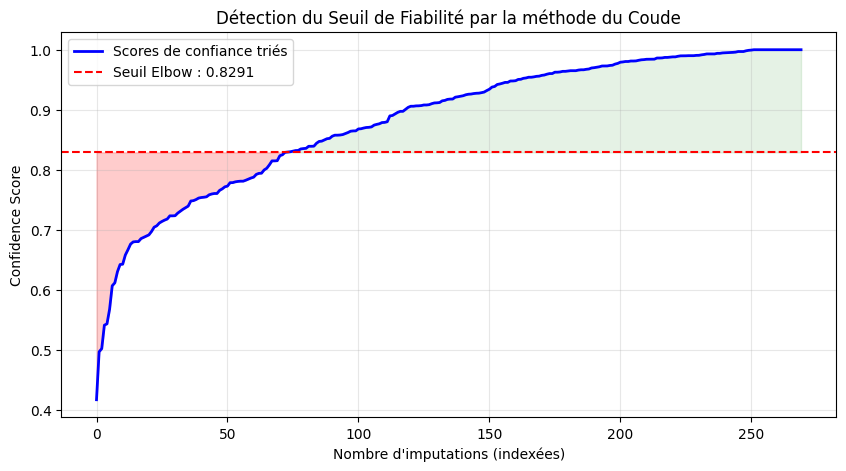

In [ ]:
def plot_elbow_viz(df, threshold):
    sorted_scores = np.sort(df['confidence_score'].values)
    plt.figure(figsize=(10, 5))
    plt.plot(sorted_scores, label='Scores de confiance triés', color='blue', lw=2)
    plt.axhline(y=threshold, color='red', linestyle='--', label=f'Seuil Elbow : {threshold:.4f}')

    # Coloration des zones
    plt.fill_between(range(len(sorted_scores)), sorted_scores, threshold,
                     where=(sorted_scores < threshold), color='red', alpha=0.2)
    plt.fill_between(range(len(sorted_scores)), sorted_scores, threshold,
                     where=(sorted_scores >= threshold), color='green', alpha=0.1)

    plt.title("Détection du Seuil de Fiabilité par la méthode du Coude")
    plt.xlabel("Nombre d'imputations (indexées)")
    plt.ylabel("Confidence Score")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_elbow_viz(results_df, elbow_threshold)

#2. Histogramme

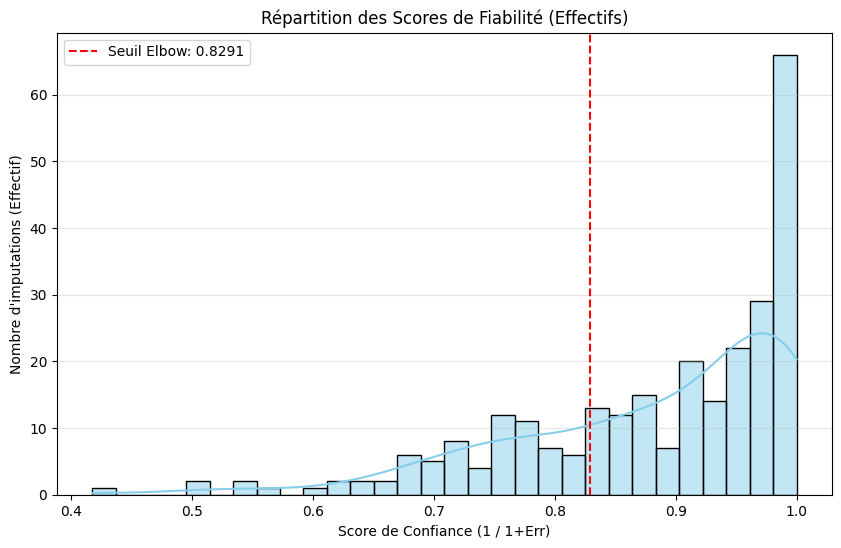

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Histogramme avec courbe de densité
sns.histplot(results_df['confidence_score'], bins=30, kde=True, color='skyblue', edgecolor='black')

# Ajout de la ligne du seuil Elbow
plt.axvline(elbow_threshold, color='red', linestyle='--', label=f'Seuil Elbow: {elbow_threshold:.4f}')

plt.title("Répartition des Scores de Fiabilité (Effectifs)")
plt.xlabel("Score de Confiance (1 / 1+Err)")
plt.ylabel("Nombre d'imputations (Effectif)")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

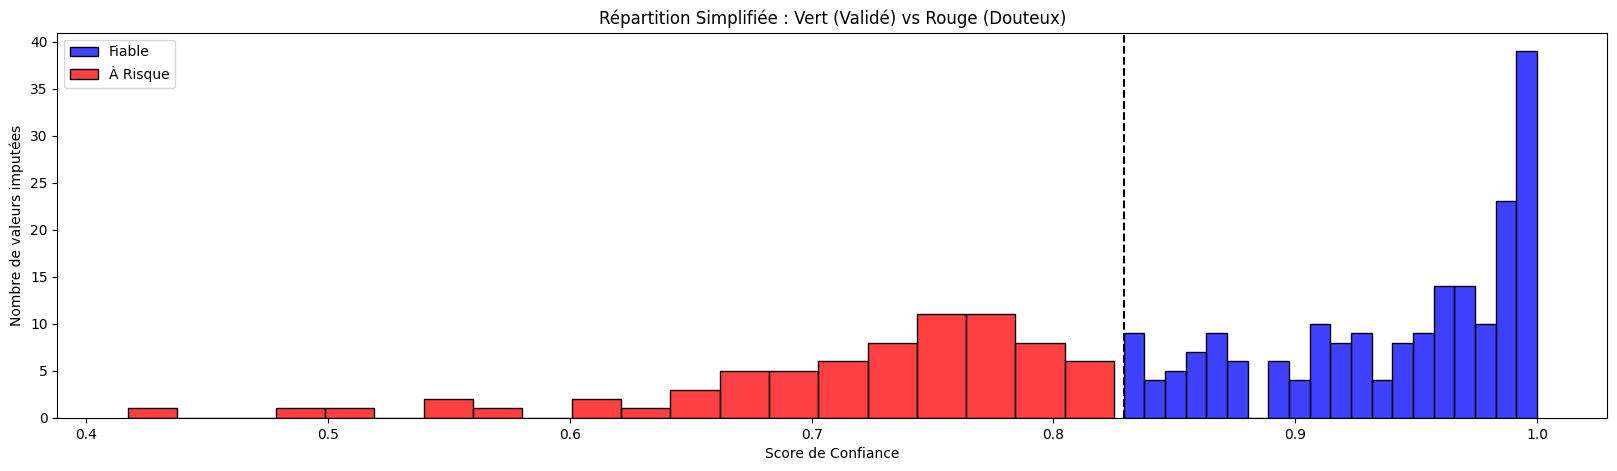

In [ ]:
plt.figure(figsize=(20, 5))
# On sépare les données pour colorer l'histogramme
sns.histplot(results_df[results_df['confidence_score'] >= elbow_threshold]['confidence_score'],
             color='blue', label='Fiable', kde=False, bins=20)
sns.histplot(results_df[results_df['confidence_score'] < elbow_threshold]['confidence_score'],
             color='red', label='À Risque', kde=False, bins=20)

plt.axvline(elbow_threshold, color='black', linestyle='--')
plt.title("Répartition Simplifiée : Vert (Validé) vs Rouge (Douteux)")
plt.xlabel("Score de Confiance")
plt.ylabel("Nombre de valeurs imputées")
plt.legend()
plt.show()

# 3.Box Plot

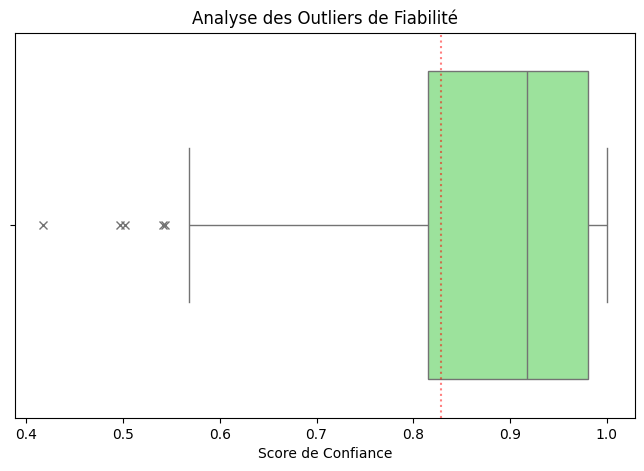

In [ ]:
plt.figure(figsize=(8, 5))
# On trace le boxplot sur la colonne de score
sns.boxplot(x=results_df['confidence_score'], color='lightgreen', flierprops={"marker": "x", "markerfacecolor": "red"})

# On marque la zone sous le seuil
plt.axvline(elbow_threshold, color='red', alpha=0.5, linestyle=':')

plt.title("Analyse des Outliers de Fiabilité")
plt.xlabel("Score de Confiance")
plt.show()

# 4.Marginal Plot

<Figure size 1000x600 with 0 Axes>

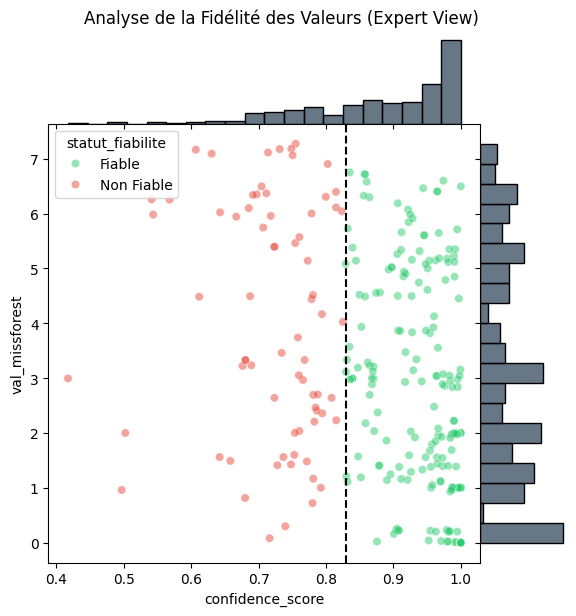

In [ ]:
plt.figure(figsize=(10, 6))
g = sns.JointGrid(data=results_df, x='confidence_score', y='val_missforest', space=0)
g.plot_joint(sns.scatterplot, hue=results_df['statut_fiabilite'], palette={'Fiable':'#2ecc71', 'Non Fiable':'#e74c3c'}, alpha=0.5)
g.plot_marginals(sns.histplot, color="#34495e", fill=True, bins=20)
g.ax_joint.axvline(elbow_threshold, color='black', linestyle='--')
plt.suptitle("Analyse de la Fidélité des Valeurs (Expert View)", y=1.02)
plt.show()